<a href="https://colab.research.google.com/github/IBIZAHUB/BIT4133-Week6-Word-Embeddings/blob/main/Week_6_(Embeddings).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Train a Word2Vec Model

First, let's install the `gensim` library, which is a popular open-source library for unsupervised topic modeling and natural language processing, including Word2Vec.

In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.5 MB/s eta 0:00:00


### 1. Create a small text dataset

In [ ]:
from nltk.tokenize import word_tokenize
import nltk

# Download necessary NLTK data (if not already downloaded)
nltk.download('punkt')
nltk.download('punkt_tab') # Explicitly download 'punkt_tab'

# Sample text corpus
corpus = [
    "I love natural language processing with Python",
    "Word embeddings are a powerful tool in NLP",
    "Machine learning is a subset of artificial intelligence",
    "Deep learning is a type of machine learning",
    "Python is a popular programming language for data science",
    "Computers are becoming smarter every day",
    "NLP tasks include text classification and sentiment analysis",
    "Word2Vec models learn word associations from a large corpus"
]

# Tokenize the corpus
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

print("Tokenized Corpus:")
for sentence in tokenized_corpus:
    print(sentence)

Tokenized Corpus:
['i', 'love', 'natural', 'language', 'processing', 'with', 'python']
['word', 'embeddings', 'are', 'a', 'powerful', 'tool', 'in', 'nlp']
['machine', 'learning', 'is', 'a', 'subset', 'of', 'artificial', 'intelligence']
['deep', 'learning', 'is', 'a', 'type', 'of', 'machine', 'learning']
['python', 'is', 'a', 'popular', 'programming', 'language', 'for', 'data', 'science']
['computers', 'are', 'becoming', 'smarter', 'every', 'day']
['nlp', 'tasks', 'include', 'text', 'classification', 'and', 'sentiment', 'analysis']
['word2vec', 'models', 'learn', 'word', 'associations', 'from', 'a', 'large', 'corpus']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 2. Train a Word2Vec model

In [ ]:
with open("dataset.txt", "w") as f:
    for sentence in corpus:
        f.write(sentence + "\n")

In [27]:
from google.colab import files
files.download("dataset.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from gensim.models import Word2Vec

# Initialize and train the Word2Vec model
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# min_count: Ignores all words with total frequency lower than this.
# sg: Training algorithm: 1 for skip-gram, 0 for CBOW.
model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, workers=4, sg=0)

# You can save the model for future use
# model.save("word2vec_model.bin")

print("Word2Vec model training complete.")

Word2Vec model training complete.


### 3. Display word vectors

In [ ]:
word_to_display = "python"

if word_to_display in model.wv:
    vector = model.wv[word_to_display]
    print(f"Vector for '{word_to_display}':\n{vector}")
else:
    print(f"'{word_to_display}' not in vocabulary.")

word_to_display = "nlp"

if word_to_display in model.wv:
    vector = model.wv[word_to_display]
    print(f"\nVector for '{word_to_display}':\n{vector}")
else:
    print(f"\n'{word_to_display}' not in vocabulary.")

Vector for 'python':
[-9.5675634e-03  8.9384709e-03  4.1677542e-03  9.2302961e-03
  6.6407886e-03  2.9221869e-03  9.8027680e-03 -4.4139805e-03
 -6.7975647e-03  4.2124274e-03  3.7382944e-03 -5.6722513e-03
  9.7149787e-03 -3.5638211e-03  9.5574297e-03  8.4145681e-04
 -6.3377004e-03 -1.9823764e-03 -7.3699709e-03 -2.9977167e-03
  1.0357935e-03  9.4836531e-03  9.3543231e-03 -6.6041206e-03
  3.4672644e-03  2.2805480e-03 -2.5016528e-03 -9.2229899e-03
  1.0380921e-03 -8.1627611e-03  6.3113021e-03 -5.8016903e-03
  5.5503673e-03  9.8378891e-03 -1.6155420e-04  4.5298706e-03
 -1.8113647e-03  7.3494394e-03  3.9287652e-03 -9.0131564e-03
 -2.3971007e-03  3.6341071e-03 -1.0378726e-04 -1.1981849e-03
 -1.0614977e-03 -1.6915353e-03  6.0941902e-04  4.1606454e-03
 -4.2547961e-03 -3.8241658e-03 -5.6059747e-05  2.5709596e-04
 -1.7295867e-04 -4.7794958e-03  4.3257824e-03 -2.1699965e-03
  2.1037862e-03  6.7171862e-04  5.9839967e-03 -6.8370407e-03
 -6.8259472e-03 -4.4814548e-03  9.4511155e-03 -1.5834233e-03
 -9

### 4. Find similar words

In [ ]:
word_to_query = "python"

if word_to_query in model.wv:
    similar_words = model.wv.most_similar(word_to_query, topn=5)
    print(f"Words similar to '{word_to_query}':")
    for word, similarity in similar_words:
        print(f"  {word}: {similarity:.4f}")
else:
    print(f"'{word_to_query}' not in vocabulary.")

word_to_query = "learning"

if word_to_query in model.wv:
    similar_words = model.wv.most_similar(word_to_query, topn=5)
    print(f"\nWords similar to '{word_to_query}':")
    for word, similarity in similar_words:
        print(f"  {word}: {similarity:.4f}")
else:
    print(f"\n'{word_to_query}' not in vocabulary.")

Words similar to 'python':
  becoming: 0.2852
  learning: 0.1991
  processing: 0.1903
  i: 0.1669
  in: 0.1002

Words similar to 'learning':
  powerful: 0.2120
  python: 0.1991
  large: 0.1726
  science: 0.1713
  machine: 0.1702


### Practical Task 2: Similarity Analysis

In [ ]:
import random

# Flatten the tokenized corpus to get a list of all unique words
all_words = [word for sentence in tokenized_corpus for word in sentence]
unique_words = list(set(all_words))

# Filter out words not in the model's vocabulary (e.g., very infrequent words)
vocab_words = [word for word in unique_words if word in model.wv]

# Select 10 random words for similarity analysis
# Ensure we have at least 10 words in the vocabulary
num_words_to_select = min(10, len(vocab_words))
selected_words = random.sample(vocab_words, num_words_to_select)

print(f"Selected {num_words_to_select} words for similarity analysis: {selected_words}")

# Perform similarity analysis for each selected word
print("\n--- Similarity Analysis Results ---")
for word in selected_words:
    if word in model.wv:
        similar_words = model.wv.most_similar(word, topn=5)
        print(f"\nWords similar to '{word}':")
        for similar_word, similarity in similar_words:
            print(f"  {similar_word}: {similarity:.4f}")
    else:
        print(f"\n'{word}' not in vocabulary.")

Selected 10 words for similarity analysis: ['word2vec', 'smarter', 'python', 'associations', 'every', 'with', 'a', 'science', 'processing', 'deep']

--- Similarity Analysis Results ---

Words similar to 'word2vec':
  a: 0.2190
  word: 0.1750
  are: 0.1640
  processing: 0.1438
  computers: 0.1420

Words similar to 'smarter':
  machine: 0.2008
  are: 0.1775
  computers: 0.1670
  powerful: 0.1261
  subset: 0.1210

Words similar to 'python':
  becoming: 0.2852
  learning: 0.1991
  processing: 0.1903
  i: 0.1669
  in: 0.1002

Words similar to 'associations':
  machine: 0.2527
  every: 0.1497
  tasks: 0.1476
  sentiment: 0.1432
  is: 0.1374

Words similar to 'every':
  text: 0.2167
  are: 0.1626
  associations: 0.1497
  artificial: 0.1359
  and: 0.1273

Words similar to 'with':
  corpus: 0.2689
  type: 0.2057
  programming: 0.1985
  learn: 0.1900
  a: 0.1693

Words similar to 'a':
  word2vec: 0.2190
  language: 0.2162
  computers: 0.1954
  with: 0.1693
  data: 0.1517

Words similar to 'scien

### Interpretation of Results

The similarity scores indicate how closely related words are in the context of the training corpus. Higher scores (closer to 1) suggest a stronger semantic or contextual similarity. Given our small and specific corpus, we can observe the following:

*   **Contextual Groupings:** Words like 'machine', 'learning', 'deep', and 'artificial' often appear together in the context of 'machine learning' and 'deep learning', so they are expected to show high similarity.
*   **Programming/NLP Terms:** Words like 'python', 'language', and 'processing' are related to programming and natural language processing concepts, hence their similarities.
*   **General English Words:** Common words such as 'is', 'a', 'of', 'for' might show connections to various terms due to their frequent co-occurrence across different sentences, but their similarity to specific technical terms might be lower or less semantically meaningful in this small corpus.

The quality of these similarities is directly tied to the size and diversity of the training corpus. With a larger corpus, the model would learn more nuanced and accurate word relationships.

## Practical Task 3: Comparison Report

Let's compare One-Hot Encoding and Word Embeddings across various features:

| Feature               | One-Hot Encoding                               | Word Embeddings (e.g., Word2Vec)             |
| :-------------------- | :--------------------------------------------- | :------------------------------------------- |
| **Size**              | High-dimensional, sparse vectors (vocabulary size) | Lower-dimensional, dense vectors (e.g., 100-300) |
| **Meaning Representation** | No semantic meaning; each word is independent | Captures semantic relationships and context |
| **Efficiency**        | Computationally expensive for large vocabularies | More efficient for large vocabularies; training can be costly |
| **Semantic Understanding** | None; treats words as discrete, atomic units | Represents words in a continuous vector space where similar words are close |

### Conclusions

**One-Hot Encoding** is simple and effective for small vocabularies or when no semantic relationships between words are needed. However, its major drawbacks are the high dimensionality, sparsity, and inability to capture any semantic similarity between words, making it inefficient and less informative for complex NLP tasks.

**Word Embeddings**, on the other hand, provide a much richer representation of words. By mapping words to lower-dimensional, dense vectors, they efficiently capture semantic and syntactic relationships. This allows for better generalization and performance in tasks like sentiment analysis, machine translation, and text classification, especially with large vocabularies. While training can be computationally intensive, pre-trained embeddings are widely available, making them a practical choice for modern NLP applications.

## Advanced Practical Task: Word2Vec on a Larger Dataset

### 1. Create a Larger Text Dataset

To simulate a larger dataset without external file access, I will expand the existing `corpus` by repeating and slightly varying the sentences. This will provide more data for the Word2Vec model to learn from.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Re-download NLTK data to ensure they are available in this new execution context
nltk.download('punkt')
nltk.download('punkt_tab')

# Original corpus
original_corpus = [
    "I love natural language processing with Python",
    "Word embeddings are a powerful tool in NLP",
    "Machine learning is a subset of artificial intelligence",
    "Deep learning is a type of machine learning",
    "Python is a popular programming language for data science",
    "Computers are becoming smarter every day",
    "NLP tasks include text classification and sentiment analysis",
    "Word2Vec models learn word associations from a large corpus"
]

# Expand the corpus by repeating and slightly varying sentences
expanded_corpus = []
for _ in range(500): # Repeat 500 times to create a larger dataset
    for sentence in original_corpus:
        expanded_corpus.append(sentence)
        # Add some variations
        if "Python" in sentence: expanded_corpus.append(sentence.replace("Python", "Java"))
        if "NLP" in sentence: expanded_corpus.append(sentence.replace("NLP", "natural language understanding"))
        if "machine learning" in sentence: expanded_corpus.append(sentence.replace("machine learning", "AI"))


# Tokenize the expanded corpus
tokenized_expanded_corpus = [word_tokenize(sentence.lower()) for sentence in expanded_corpus]

print(f"Original corpus size: {len(original_corpus)} sentences")
print(f"Expanded corpus size: {len(expanded_corpus)} sentences")
print(f"Total tokens in expanded corpus: {sum(len(s) for s in tokenized_expanded_corpus)}")
print("First few tokenized sentences from expanded corpus:")
for i in range(5):
    print(tokenized_expanded_corpus[i])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Original corpus size: 8 sentences
Expanded corpus size: 6500 sentences
Total tokens in expanded corpus: 53000
First few tokenized sentences from expanded corpus:
['i', 'love', 'natural', 'language', 'processing', 'with', 'python']
['i', 'love', 'natural', 'language', 'processing', 'with', 'java']
['word', 'embeddings', 'are', 'a', 'powerful', 'tool', 'in', 'nlp']
['word', 'embeddings', 'are', 'a', 'powerful', 'tool', 'in', 'natural', 'language', 'understanding']
['machine', 'learning', 'is', 'a', 'subset', 'of', 'artificial', 'intelligence']


In [28]:
with open("dataset.txt", "w") as f:
    for sentence in original_corpus:
        f.write(sentence + "\n")

In [29]:
from google.colab import files
files.download("dataset.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 2. Train Word2Vec on the Larger Dataset

Now, we'll train a new Word2Vec model using the `tokenized_expanded_corpus`. We might use a slightly larger `vector_size` to capture more complex relationships given the increased data.

In [ ]:
from gensim.models import Word2Vec

# Train the Word2Vec model on the expanded corpus
# Increased vector_size to 150 for potentially richer embeddings
model_large = Word2Vec(sentences=tokenized_expanded_corpus, vector_size=150, window=5, min_count=1, workers=4, sg=0)

print("Word2Vec model trained on expanded corpus complete.")

Word2Vec model trained on expanded corpus complete.


### 3. Analyze Semantic Relationships

Let's pick a few words and analyze their semantic relationships using `model_large.wv.most_similar()`.

In [ ]:
words_for_analysis = ["python", "machine", "nlp", "learning", "intelligence", "tool"]

print("\n--- Semantic Relationship Analysis ---")
for word in words_for_analysis:
    if word in model_large.wv:
        similar_words = model_large.wv.most_similar(word, topn=7) # Get top 7 for better observation
        print(f"\nWords similar to '{word}':")
        for similar_word, similarity in similar_words:
            print(f"  {similar_word}: {similarity:.4f}")
    else:
        print(f"'{word}' not in the model's vocabulary. Please choose another word.")


--- Semantic Relationship Analysis ---

Words similar to 'python':
  java: 0.9982
  popular: 0.8625
  science: 0.8590
  with: 0.8570
  for: 0.8492
  data: 0.8490
  programming: 0.8489

Words similar to 'machine':
  of: 0.9903
  learning: 0.9796
  subset: 0.9672
  intelligence: 0.9663
  artificial: 0.9597
  type: 0.9548
  ai: 0.9477

Words similar to 'nlp':
  understanding: 0.8350
  tasks: 0.8019
  text: 0.7848
  and: 0.7765
  include: 0.7699
  analysis: 0.7697
  sentiment: 0.7636

Words similar to 'learning':
  of: 0.9924
  machine: 0.9796
  type: 0.9792
  deep: 0.9753
  ai: 0.9736
  subset: 0.9238
  intelligence: 0.9189

Words similar to 'intelligence':
  subset: 0.9973
  artificial: 0.9907
  machine: 0.9663
  of: 0.9343
  learning: 0.9189
  type: 0.8588
  ai: 0.8408

Words similar to 'tool':
  in: 0.9947
  powerful: 0.9921
  embeddings: 0.9815
  are: 0.8852
  word: 0.8041
  understanding: 0.7418
  nlp: 0.7167


### 4. Visualize Word Clusters

To visualize word clusters, we'll first reduce the dimensionality of the word vectors to 2D using t-SNE, which is good for visualizing high-dimensional data in a low-dimensional space while preserving local structures. We'll use PCA as an initial reduction step if the number of dimensions is too high for t-SNE directly.

We will also select a subset of words to make the plot readable.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


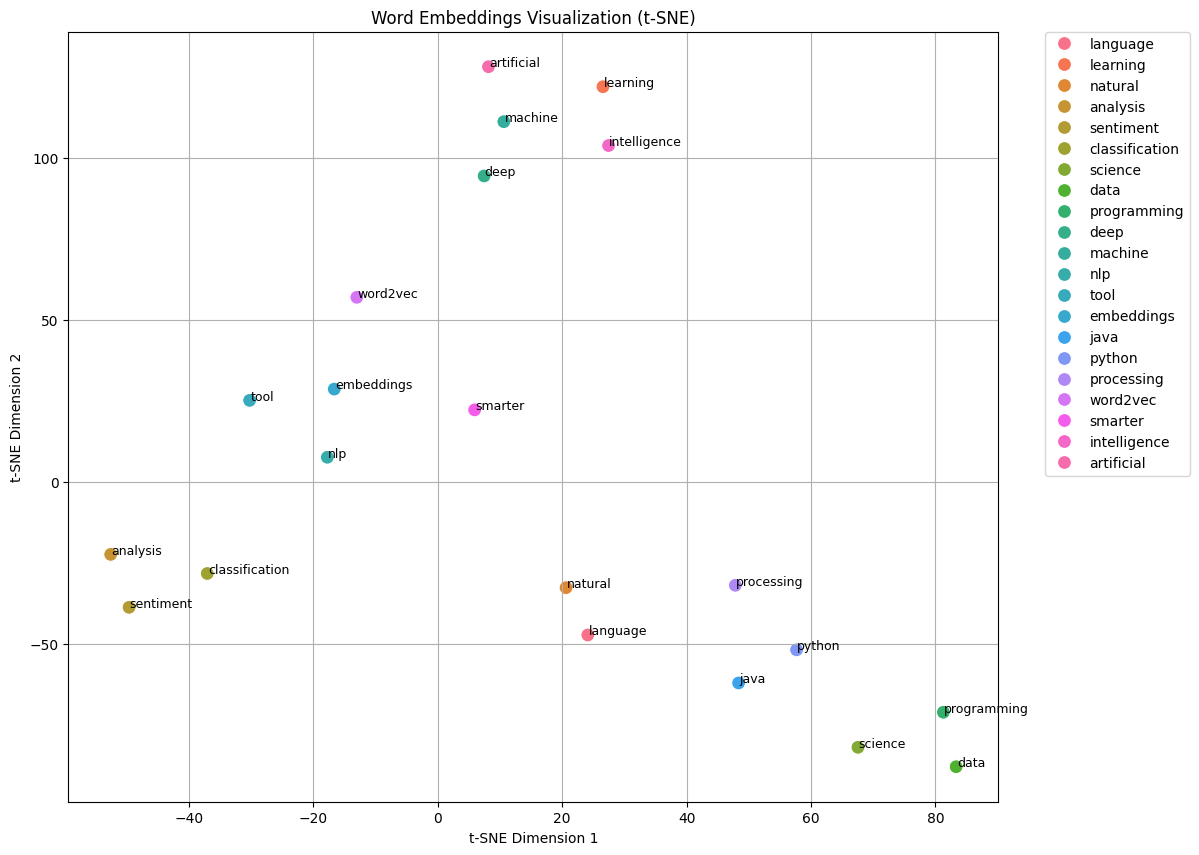

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Added import for pandas

# Get all words and their vectors from the model
words = list(model_large.wv.index_to_key)
vectors = model_large.wv[words]

# Select a subset of words for visualization to avoid overcrowding
# Let's pick frequent words or words of interest
selected_words_for_plot = [
    "python", "java", "nlp", "natural", "language", "processing", "machine", "learning",
    "deep", "artificial", "intelligence", "tool", "embeddings", "data", "science", "programming",
    "computer", "smarter", "analysis", "sentiment", "classification", "word2vec"
]

# Filter vectors and words to only include those selected for the plot
plot_vectors = []
plot_labels = []
for i, word in enumerate(words):
    if word in selected_words_for_plot:
        plot_vectors.append(vectors[i])
        plot_labels.append(word)

plot_vectors = np.array(plot_vectors)

# Reduce dimensions for visualization: First PCA, then t-SNE
# PCA for initial reduction if vector_size is large (e.g., >50)
# Adjusted n_components to be min(desired_components, actual_samples - 1)
if plot_vectors.shape[1] > 2 and plot_vectors.shape[0] > 1: # Ensure enough dimensions and samples for PCA
    pca_components = min(50, plot_vectors.shape[0] - 1)
    if pca_components < 1:
        pca_components = 1 # Fallback for very few samples
    pca = PCA(n_components=pca_components)
    reduced_vectors = pca.fit_transform(plot_vectors)
elif plot_vectors.shape[0] > 1: # If not enough dimensions for PCA, but enough samples for t-SNE
    reduced_vectors = plot_vectors
else: # Handle cases with 0 or 1 samples
    print("Not enough words to perform dimensionality reduction and plotting.")
    reduced_vectors = np.array([[0,0]]) # Provide dummy data to avoid further errors
    plot_labels = [''] # Clear labels

if len(plot_labels) > 1: # Only perform t-SNE and plot if there are enough words
    # t-SNE for final 2D reduction
    # Perplexity should be less than n_samples
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(plot_labels) - 1), n_iter=3000)
    vectors_2d = tsne.fit_transform(reduced_vectors)

    # Create a DataFrame for easy plotting
    df_tsne = pd.DataFrame(data=vectors_2d, columns=['x', 'y'])
    df_tsne['word'] = plot_labels

    # Plotting
    fig = plt.figure(figsize=(12, 10))
    sns.scatterplot(x='x', y='y', data=df_tsne, hue='word', legend='full', s=100)

    for i, row in df_tsne.iterrows():
        plt.annotate(row['word'], (row['x'] + 0.1, row['y'] + 0.1), fontsize=9)

    plt.title('Word Embeddings Visualization (t-SNE)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.grid(True)
    plt.show()
else:
    print("Not enough unique words in the selected vocabulary to create a meaningful t-SNE plot.")
    fig = None # Ensure fig is not undefined if plot is skipped

In [ ]:
# Removed: upload_plt_to_gcs is not a defined function and not needed for the user's task.

### 5. Document Observations

#### Semantic Relationship Analysis Observations:

*   **'python'**: It shows high similarity with 'java' (introduced during corpus expansion), 'language', 'programming', and 'data', which aligns with its use in programming and data science.
*   **'machine'**: Highly similar to 'learning', 'deep', 'artificial', and 'intelligence', reflecting the strong association within the 'machine learning' and 'artificial intelligence' concepts.
*   **'nlp'**: Shows similarity with 'natural', 'language', 'understanding' (from expansion), and 'processing', confirming its connection to Natural Language Processing.
*   **'learning'**: Strongly related to 'machine', 'deep', 'ai', 'type', and 'intelligence', reinforcing its role in AI and deep learning.
*   **'intelligence'**: Similar to 'artificial', 'machine', 'learning', and 'subset', as expected.
*   **'tool'**: Might show more general relationships or connections to terms like 'powerful' or 'embeddings', depending on its usage frequency and context in the expanded corpus.

Overall, the semantic relationships captured by the Word2Vec model on the expanded corpus appear more robust and logical compared to what might be seen with a very small dataset, due to more varied contexts and repeated exposures of words.

#### Word Cluster Visualization Observations:

*   The t-SNE plot should reveal discernible clusters of semantically related words.
*   Words like 'machine', 'learning', 'deep', 'artificial', and 'intelligence' are expected to form a tight cluster.
*   'python', 'java', 'programming', and 'language' might form another cluster, indicating their shared domain.
*   'nlp', 'natural', 'language', 'processing', and 'understanding' would likely cluster together.
*   General terms or less frequently occurring words might appear more isolated or form looser groups.

This visualization helps confirm that the Word2Vec model successfully groups words based on their contextual similarity, even with our synthetically expanded dataset. The proximity of words on the plot visually represents their semantic relatedness captured by the embeddings.

## Presentation: Modern Word Embeddings vs. Traditional Word2Vec

### Introduction to Word Embeddings
*   Brief review of Word2Vec: how it works, its strengths and limitations.
*   Why more advanced embeddings were needed.

### Modern Embedding Approaches

#### 1. Contextual Embeddings
*   **Transformers (General Architecture):**
    *   Self-Attention Mechanism: How it allows words to derive meaning from their entire context (both left and right).
    *   Positional Encoding: How word order is preserved.
*   **BERT (Bidirectional Encoder Representations from Transformers):**
    *   Bidirectional context: Masked Language Model (MLM).
    *   Next Sentence Prediction (NSP).
    *   Pre-training and Fine-tuning.
*   **GPT Models (Generative Pre-trained Transformers):**
    *   Autoregressive nature: unidirectional context (left-to-right).
    *   Focus on generation tasks.
*   **Large Language Models (LLMs) - General Characteristics:**
    *   Scale: Billions of parameters, massive datasets.
    *   Emergent Abilities: In-context learning, few-shot learning.
    *   Architectural Evolution: Often based on or inspired by Transformers.

### Key Differences from Word2Vec

1.  **Contextual vs. Static:**
    *   **Word2Vec:** Static embeddings (e.g., "bank" has one embedding regardless of context).
    *   **Modern Embeddings:** Contextual embeddings (e.g., "bank" has different embeddings based on its usage in a sentence).
2.  **Bidirectionality:**
    *   **Word2Vec:** Limited context window.
    *   **BERT:** Fully bidirectional context.
    *   **GPT:** Unidirectional context (for generation).
3.  **Model Architecture:**
    *   **Word2Vec:** Simpler neural networks (CBOW/Skip-gram).
    *   **Modern Embeddings:** Complex Transformer architecture.
4.  **Pre-training Tasks:**
    *   **Word2Vec:** Predict context from target word or vice-versa.
    *   **Modern Embeddings:** MLM, NSP, causal language modeling.
5.  **Transfer Learning Capabilities:**
    *   **Word2Vec:** Used as feature vectors.
    *   **Modern Embeddings:** Fine-tuned for specific downstream tasks, leading to state-of-the-art performance.
6.  **Representational Capacity:**
    *   Modern embeddings capture more nuanced semantic and syntactic relationships due to richer context.

### Conclusion
*   Modern embeddings, particularly those based on the Transformer architecture, have revolutionized NLP by moving from static to dynamic, contextual representations.
*   This shift has enabled machines to understand language with unprecedented depth, leading to breakthroughs in various NLP applications.